# EDA — 21 Active Matches (15-class, 3-way split)

Updated analysis reflecting:
- **15-class shot type vocabulary** (official ShuttleSet English names, drive subtypes merged)
- **3-way split**: 17 train / 2 val / 2 test (val carved from train pool)
- Fixed rally counting (set-aware)
- **Counts match `ShuttleSetDataset`** — only CSV rows whose `frame_num` has an extracted skeleton frame within ±4 are counted (training-eligible shots).

Sections:
1. Setup & Load Annotations
2. Per-Split Summary
3. Shot Type Distribution (15-class, merged drive)
4. Per-Match Shot Counts
5. Rally Length Distribution
6. Shot Duration by Type
7. Class Imbalance Analysis
8. Summary

In [1]:
import os, sys, json
from pathlib import Path

try:
    import google.colab; IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT   = Path('/content/drive/MyDrive/Baddiev2')
    PROJECT_PATH = Path('/content/Baddiev2')
    import zipfile
    if not (PROJECT_PATH / 'src').exists():
        print('Extracting project...')
        with zipfile.ZipFile(DRIVE_ROOT / 'baddiev2_colab.zip') as z:
            z.extractall(PROJECT_PATH)
    sys.path.insert(0, str(PROJECT_PATH))
    os.chdir(PROJECT_PATH)
else:
    # Walk up until we find a directory containing src/ (project root)
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / 'src').exists():
            PROJECT_PATH = cand
            break
    else:
        raise RuntimeError(f"Could not locate project root (no src/ found above {here})")
    DRIVE_ROOT = PROJECT_PATH
    if str(PROJECT_PATH) not in sys.path:
        sys.path.insert(0, str(PROJECT_PATH))

import src.config as _cfg

if IN_COLAB:
    _cfg.SS_CSV_ROOT        = DRIVE_ROOT   / 'datasets' / 'ShuttleSet' / 'set'
    _cfg.SS_MATCH_CSV       = _cfg.SS_CSV_ROOT / 'match.csv'
    _cfg.SS_SKELETONS_GDINO = DRIVE_ROOT   / 'datasets_preprocessing' / 'shuttleset_skeletons_gdino'
    _cfg.SS_SHUTTLES        = DRIVE_ROOT   / 'datasets_preprocessing' / 'shuttleset_shuttles'
    _cfg.SS_SPLIT_JSON      = PROJECT_PATH / 'datasets_preprocessing' / 'shuttleset_split.json'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from src.config import (
    SHOT_TYPES, SHOT_TYPE_TO_IDX, SS_TYPE_TO_SHOT_TYPE, NUM_SHOT_TYPES,
)
# Re-bind path constants from the (possibly mutated) _cfg so Colab overrides take effect
SS_CSV_ROOT        = _cfg.SS_CSV_ROOT
SS_MATCH_CSV       = _cfg.SS_MATCH_CSV
SS_SKELETONS_GDINO = _cfg.SS_SKELETONS_GDINO
SS_SHUTTLES        = _cfg.SS_SHUTTLES
SS_SPLIT_JSON      = _cfg.SS_SPLIT_JSON

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 10
plt.rcParams['figure.facecolor'] = 'white'

# Validation matches (carved from train pool at training time)
VAL_MATCHES = {
    'NG_Ka_Long_Angus_Jonatan_CHRISTIE_Malaysia_Masters_2020_QuarterFinals',
    'Anders_Antonsen_Sameer_Verma_TOYOTA_THAILAND_OPEN_2021_QuarterFinals',
}

SPLIT_COLORS = {'train': '#22c55e', 'val': '#f59e0b', 'test': '#a78bfa'}
SPLIT_LABELS = {'train': 'Train (17)', 'val': 'Val (2)', 'test': 'Test (2)'}

print(f"Project   : {PROJECT_PATH}")
print(f"Shot types ({NUM_SHOT_TYPES}): {SHOT_TYPES}")
print(f"CSV root  : {SS_CSV_ROOT}")
print(f"Skel root : {SS_SKELETONS_GDINO}")
print(f"Split json: {SS_SPLIT_JSON}")

Mounted at /content/drive
Extracting project...
Project   : /content/Baddiev2
Shot types (15): ['net shot', 'return net', 'smash', 'wrist smash', 'lob', 'defensive return lob', 'clear', 'drive', 'drop', 'passive drop', 'push', 'rush', 'cross-court net shot', 'short service', 'long service']
CSV root  : /content/drive/MyDrive/Baddiev2/datasets/ShuttleSet/set
Skel root : /content/drive/MyDrive/Baddiev2/datasets_preprocessing/shuttleset_skeletons_gdino
Split json: /content/Baddiev2/datasets_preprocessing/shuttleset_split.json


## 1. Load Split, CSV Annotations & Skeleton-Availability Filter

Counts in the rest of this notebook reflect the **training-eligible** subset: CSV rows whose `frame_num` has an extracted skeleton frame (within ±4 frames, matching `ShuttleSetDataset._load_whole_match_index`).

In [3]:
split_data = json.loads(SS_SPLIT_JSON.read_text())

# 3-way split
active_matches = {}
for m in split_data.get('train', []):
    active_matches[m] = 'val' if m in VAL_MATCHES else 'train'
for m in split_data.get('held_out', []):
    active_matches[m] = 'test'

for sp in ('train', 'val', 'test'):
    n = sum(1 for v in active_matches.values() if v == sp)
    print(f"  {sp:6s}: {n} matches")

# Load match metadata
match_meta = pd.read_csv(SS_MATCH_CSV)
match_meta['video'] = match_meta['video'].str.strip()
match_meta = match_meta[match_meta['video'].isin(active_matches)].copy()
match_meta['split'] = match_meta['video'].map(active_matches)
print(f"\nMatch metadata: {len(match_meta)} rows")

# Load CSV strokes AND filter by skeleton-extraction availability so the
# counts match `ShuttleSetDataset` (see src/data/dataset.py::_load_whole_match_index).
# A CSV row is kept iff its frame_num is in the match's frame_nums.npy
# (with ±4 stride tolerance).
csv_root  = Path(SS_CSV_ROOT)
skel_root = Path(SS_SKELETONS_GDINO)

all_records      = []
csv_only_total   = 0
matched_total    = 0
missing_skel_dirs = []

for match_id, sp in sorted(active_matches.items()):
    match_csv_dir  = csv_root  / match_id
    match_skel_dir = skel_root / match_id
    if not match_csv_dir.exists():
        print(f"  [WARN] Missing CSV dir: {match_id}")
        continue

    fn_path = match_skel_dir / 'frame_nums.npy'
    if fn_path.exists():
        frame_nums_arr = np.load(str(fn_path))
        fn_set = set(int(x) for x in frame_nums_arr.tolist())
    else:
        frame_nums_arr = None
        fn_set = set()
        missing_skel_dirs.append(match_id)

    for csv_path in sorted(match_csv_dir.glob('set*.csv')):
        try:
            set_num = int(''.join(filter(str.isdigit, csv_path.stem)) or '0')
        except ValueError:
            set_num = 0
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
        df['match_id']  = match_id
        df['split']     = sp
        df['set_num']   = set_num
        df['rally_uid'] = df['set_num'].astype(str) + '_' + df['rally'].astype(str)
        csv_only_total += len(df)

        # Skeleton-availability filter (replicates ShuttleSetDataset)
        if frame_nums_arr is not None:
            fn = pd.to_numeric(df['frame_num'], errors='coerce')
            in_set    = fn.map(lambda v: (not pd.isna(v)) and int(v) in fn_set)
            within_4  = fn.map(
                lambda v: (not pd.isna(v)) and
                          np.any(np.abs(frame_nums_arr - int(v)) <= 4)
            )
            df['has_skeleton'] = in_set | within_4
        else:
            df['has_skeleton'] = False

        matched_total += int(df['has_skeleton'].sum())
        all_records.append(df)

# Two views:
#   strokes_raw — every CSV row across the 21 active matches (annotation set)
#   strokes     — rows with extracted skeletons (matches ShuttleSetDataset)
strokes_raw = pd.concat(all_records, ignore_index=True)
strokes_raw['shot_type'] = strokes_raw['type'].map(SS_TYPE_TO_SHOT_TYPE)

strokes = strokes_raw[strokes_raw['has_skeleton']].copy()
strokes['shot_type'] = strokes['type'].map(SS_TYPE_TO_SHOT_TYPE)

if missing_skel_dirs:
    print(f"\n[WARN] {len(missing_skel_dirs)} matches have CSV but no frame_nums.npy "
          f"(samples excluded): {missing_skel_dirs[:3]}{'…' if len(missing_skel_dirs)>3 else ''}")

print(f"\nCSV strokes (raw)          : {csv_only_total:,}")
print(f"Strokes w/ extracted skel  : {matched_total:,}  ← matches ShuttleSetDataset")
print(f"  ├─ labelled              : {strokes['shot_type'].notna().sum():,}")
print(f"  └─ unknown/unmapped      : {strokes['shot_type'].isna().sum():,}")
strokes.head(3)

  train : 17 matches
  val   : 2 matches
  test  : 2 matches

Match metadata: 21 rows

CSV strokes (raw)          : 19,470
Strokes w/ extracted skel  : 19,470  ← matches ShuttleSetDataset
  ├─ labelled              : 18,637
  └─ unknown/unmapped      : 833


,rally,ball_round,time,frame_num,roundscore_A,roundscore_B,player,server,type,aroundhead,...,opponent_location_area,opponent_location_x,opponent_location_y,db,match_id,split,set_num,rally_uid,has_skeleton,shot_type
0,1,1.0,00:06:31,11754.0,1,0,A,1,發長球,NaN,...,8.0,747.0,557.0,0,Anders_Antonsen_Sameer_Verma_TOYOTA_THAILAND_O...,val,1,1_1,True,long service
1,1,2.0,00:06:32,11788.0,1,0,B,2,點扣,NaN,...,8.0,632.0,359.0,0,Anders_Antonsen_Sameer_Verma_TOYOTA_THAILAND_O...,val,1,1_1,True,wrist smash
2,1,3.0,00:06:34,11825.0,1,0,A,2,擋小球,NaN,...,8.0,775.0,614.0,0,Anders_Antonsen_Sameer_Verma_TOYOTA_THAILAND_O...,val,1,1_1,True,return net


## 2. Per-Split Summary

In [6]:
split_summary = strokes.groupby('split').agg(
    matches  =('match_id', 'nunique'),
    rallies  =('rally_uid', lambda x: x[strokes.loc[x.index, 'match_id'].map(
                   lambda m: True)].nunique()),
    shots    =('type', 'count'),
    labelled =('shot_type', 'count'),
).reindex(['train', 'val', 'test'])

# Simpler: compute rallies via set-aware groupby
rally_uid_counts = (strokes.groupby(['split', 'match_id', 'rally_uid'])
                    .size().reset_index(name='n'))
rally_per_split  = rally_uid_counts.groupby('split')['rally_uid'].count()
split_summary['rallies'] = rally_per_split

split_summary['shots_pct'] = (split_summary['shots'] / split_summary['shots'].sum() * 100).round(1)
split_summary['avg_shots_per_rally'] = (split_summary['shots'] / split_summary['rallies']).round(1)

print("=" * 70)
print("SPLIT SUMMARY")
print("=" * 70)
print(split_summary[['matches','rallies','shots','labelled','shots_pct','avg_shots_per_rally']].to_string())
print(f"\nTotal: {split_summary['matches'].sum()} matches, "
      f"{split_summary['rallies'].sum()} rallies, "
      f"{split_summary['shots'].sum():,} shots (total strokes with extracted skeletons)")
labelled_shots_count = strokes['shot_type'].notna().sum()
unmapped_shots_count = strokes['shot_type'].isna().sum()
print(f"       ({labelled_shots_count:,} of these shots have a recognized type; "
      f"{unmapped_shots_count:,} are unmapped/unknown.)")

# Per-match breakdown
print("\n" + "-"*70)
per_match = (strokes.groupby(['split', 'match_id'])
             .agg(shots=('type','count'),
                  rallies=('rally_uid','nunique'))
             .reset_index()
             .sort_values(['split','shots'], ascending=[True,False]))
for sp in ('train', 'val', 'test'):
    sub = per_match[per_match['split'] == sp]
    print(f"\n{sp.upper()} ({len(sub)} matches, {sub['shots'].sum():,} shots, {sub['rallies'].sum()} rallies):")
    for _, r in sub.iterrows():
        short = r['match_id'].replace('_',' ')[:55]
        print(f"  {r['shots']:5d} shots  {r['rallies']:3d} rallies  {short}")

SPLIT SUMMARY
       matches  rallies  shots  labelled  shots_pct  avg_shots_per_rally
split                                                                   
train       17     1584  15640     14933       80.3                  9.9
val          2      212   2155      2077       11.1                 10.2
test         2      178   1675      1627        8.6                  9.4

Total: 21 matches, 1974 rallies, 19,470 shots (total strokes with extracted skeletons)
       (18,637 of these shots have a recognized type; 833 are unmapped/unknown.)

----------------------------------------------------------------------

TRAIN (17 matches, 15,640 shots, 1584 rallies):
   1424 shots  176 rallies  Anthony Sinisuka GINTING Anders ANTONSEN Indonesia Mast
   1361 shots  116 rallies  Viktor Axelsen Hans-Kristian Solberg VIittinghus TOYOTA
   1344 shots  104 rallies  Viktor Axelsen Ng Ka Long Angus YONEX Thailand Open 202
   1273 shots  115 rallies  Hans-Kristian Solberg Vittinghus Lee Cheuk Yu TOYOT

## 3. Shot Type Distribution (15-class, drive merged)

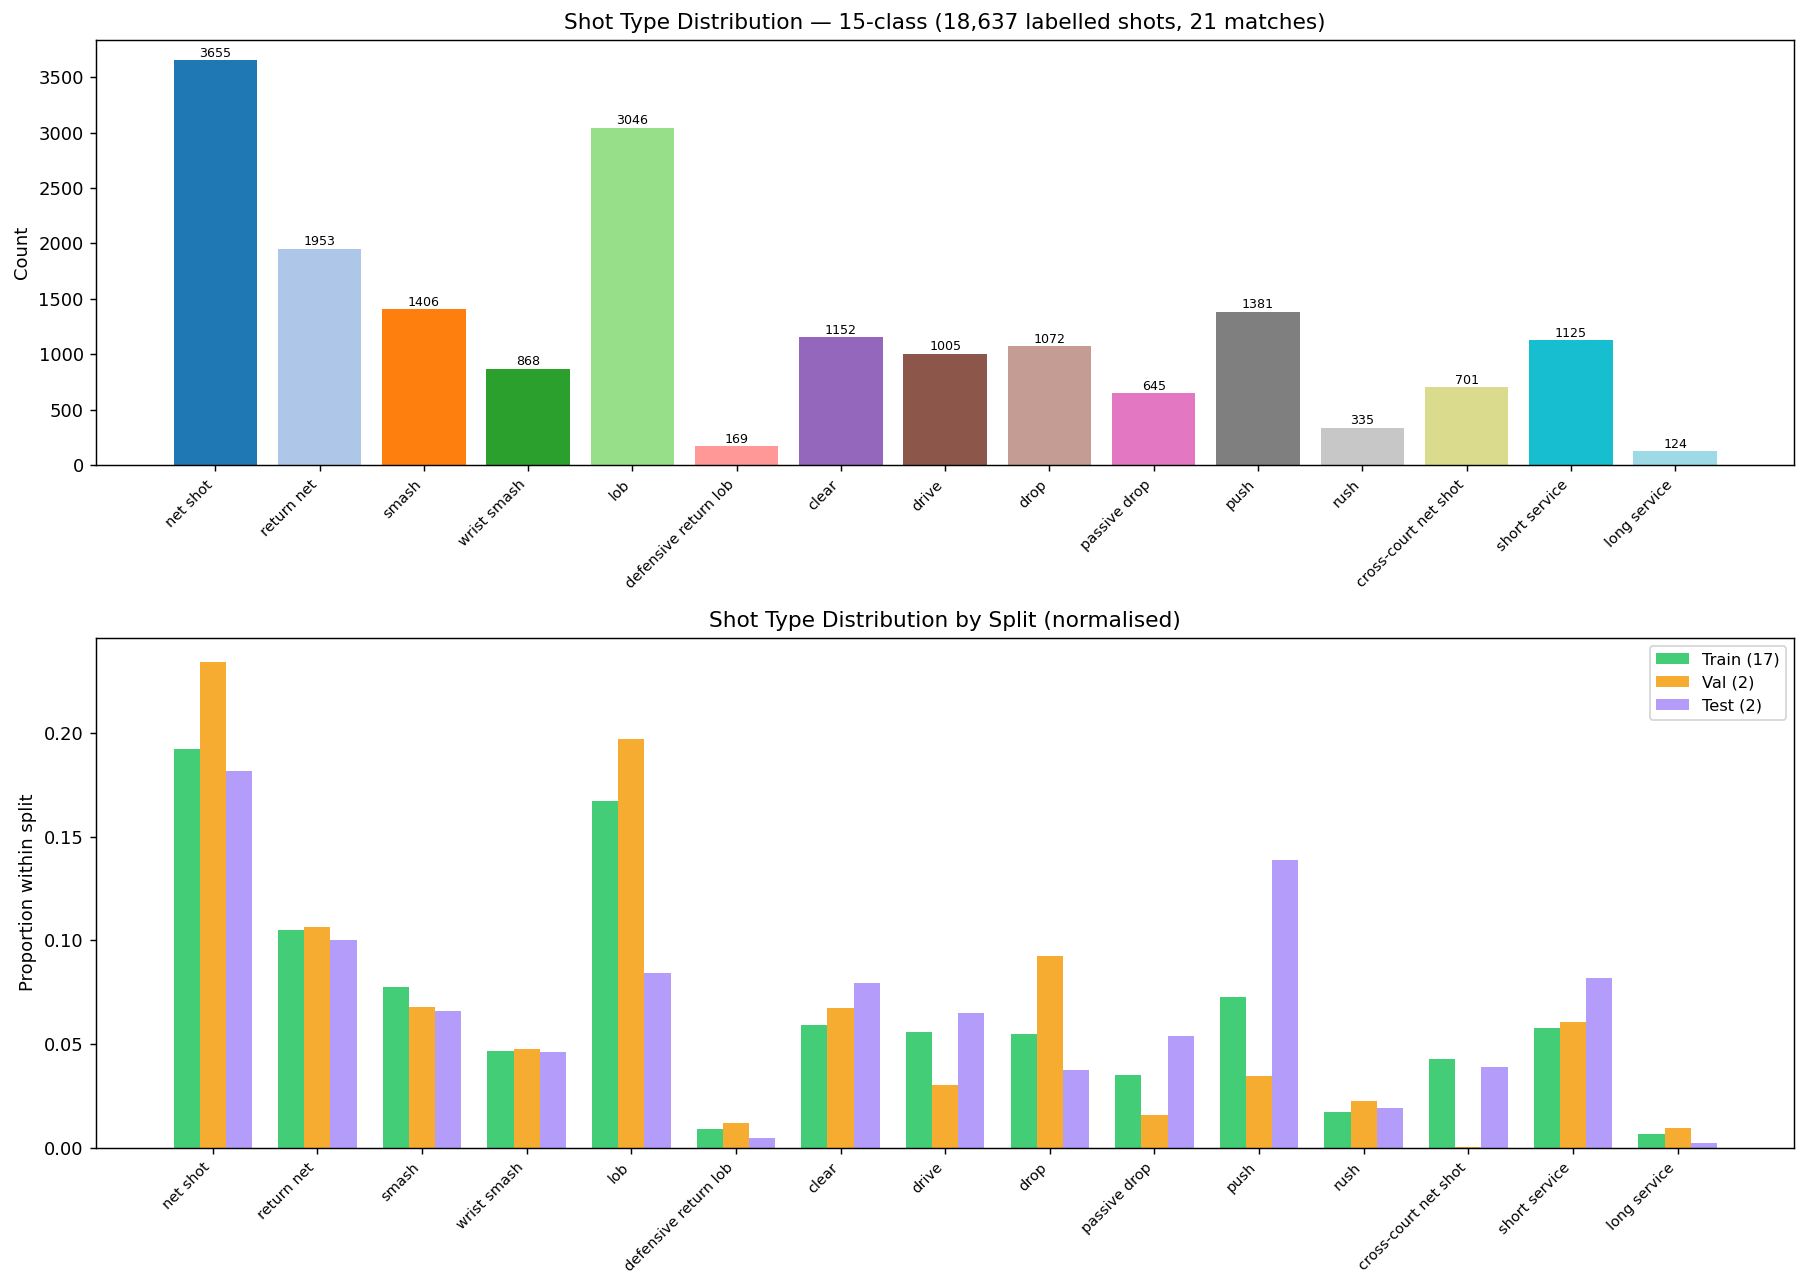

Imbalance ratio (max/min): 29.5x

Shot type                   Count      %
----------------------------------------
  net shot                   3655   19.6%
  return net                 1953   10.5%
  smash                      1406    7.5%
  wrist smash                 868    4.7%
  lob                        3046   16.3%
  defensive return lob        169    0.9%
  clear                      1152    6.2%
  drive                      1005    5.4%
  drop                       1072    5.8%
  passive drop                645    3.5%
  push                       1381    7.4%
  rush                        335    1.8%
  cross-court net shot        701    3.8%
  short service              1125    6.0%
  long service                124    0.7%
  TOTAL                     18637


In [5]:
labelled = strokes[strokes['shot_type'].notna()].copy()

# Counts in SHOT_TYPES order
type_counts = labelled['shot_type'].value_counts()
ordered_counts = [type_counts.get(s, 0) for s in SHOT_TYPES]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 1.2]})

# Overall bar chart
colors = plt.cm.tab20(np.linspace(0, 1, len(SHOT_TYPES)))
bars = axes[0].bar(range(len(SHOT_TYPES)), ordered_counts, color=colors)
axes[0].set_xticks(range(len(SHOT_TYPES)))
axes[0].set_xticklabels(SHOT_TYPES, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Count')
axes[0].set_title(f'Shot Type Distribution — 15-class ({labelled.shape[0]:,} labelled shots, 21 matches)')
for bar, cnt in zip(bars, ordered_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(cnt), ha='center', va='bottom', fontsize=7)

# Per-split normalised
split_type = labelled.groupby(['split','shot_type']).size().unstack(fill_value=0)
split_type = split_type.reindex(index=['train','val','test'], columns=SHOT_TYPES, fill_value=0)
split_pct  = split_type.div(split_type.sum(axis=1), axis=0)

x = np.arange(len(SHOT_TYPES))
w = 0.25
for i, sp in enumerate(['train','val','test']):
    axes[1].bar(x + (i-1)*w, split_pct.loc[sp].values, w,
                label=SPLIT_LABELS[sp], color=SPLIT_COLORS[sp], alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(SHOT_TYPES, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Proportion within split')
axes[1].set_title('Shot Type Distribution by Split (normalised)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

total_labelled = sum(ordered_counts)
imbalance = max(ordered_counts) / min(c for c in ordered_counts if c > 0)
print(f"Imbalance ratio (max/min): {imbalance:.1f}x")
print(f"\n{'Shot type':<26} {'Count':>6}  {'%':>5}")
print("-"*40)
for s, n in zip(SHOT_TYPES, ordered_counts):
    print(f"  {s:<24} {n:6d}  {n/total_labelled*100:5.1f}%")
print(f"  {'TOTAL':<24} {total_labelled:6d}")

## 4. Per-Match Shot Counts Heatmap

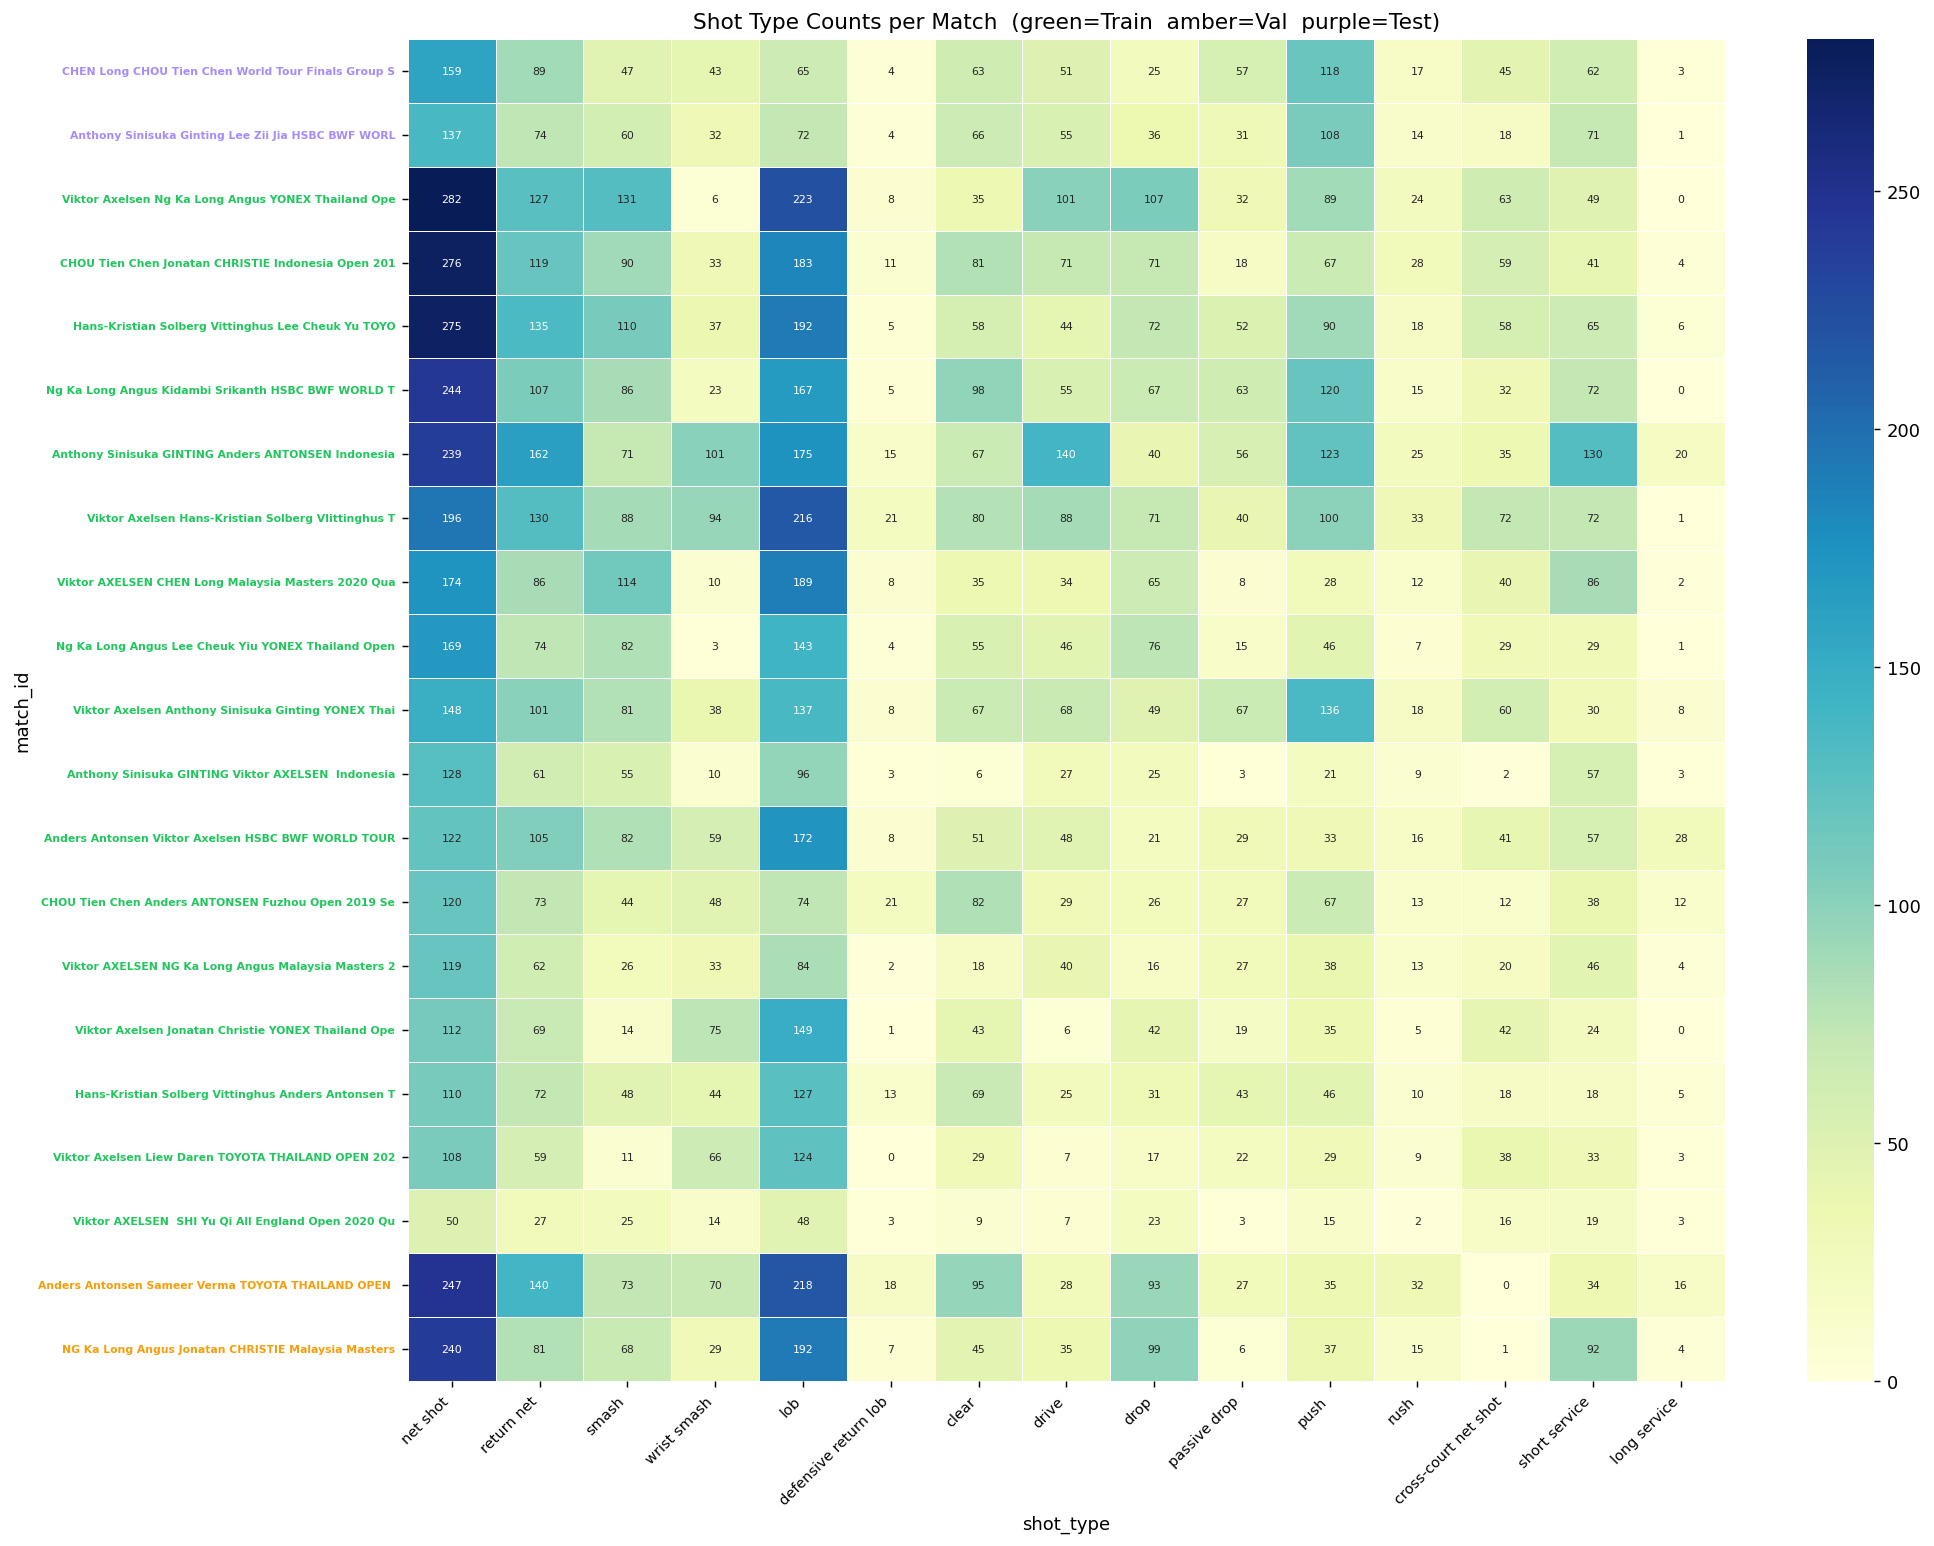

In [7]:
spm = labelled.groupby(['match_id','shot_type']).size().unstack(fill_value=0)
spm = spm.reindex(columns=SHOT_TYPES, fill_value=0)

split_map = strokes.groupby('match_id')['split'].first()
spm['_split'] = spm.index.map(split_map)
spm = spm.sort_values(['_split', 'net shot'], ascending=[True, False])
split_labels_row = spm['_split'].values
spm = spm.drop(columns='_split')

row_labels = [m.replace('_',' ')[:50] for m in spm.index]
row_colors = [SPLIT_COLORS.get(s, '#888') for s in split_labels_row]

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(spm, annot=True, fmt='d', cmap='YlGnBu',
            ax=ax, linewidths=0.3, annot_kws={'size': 6})
ax.set_yticklabels(row_labels, fontsize=6)
for label, color in zip(ax.get_yticklabels(), row_colors):
    label.set_color(color)
    label.set_fontweight('bold')
ax.set_title('Shot Type Counts per Match  (green=Train  amber=Val  purple=Test)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

## 5. Rally Length Distribution

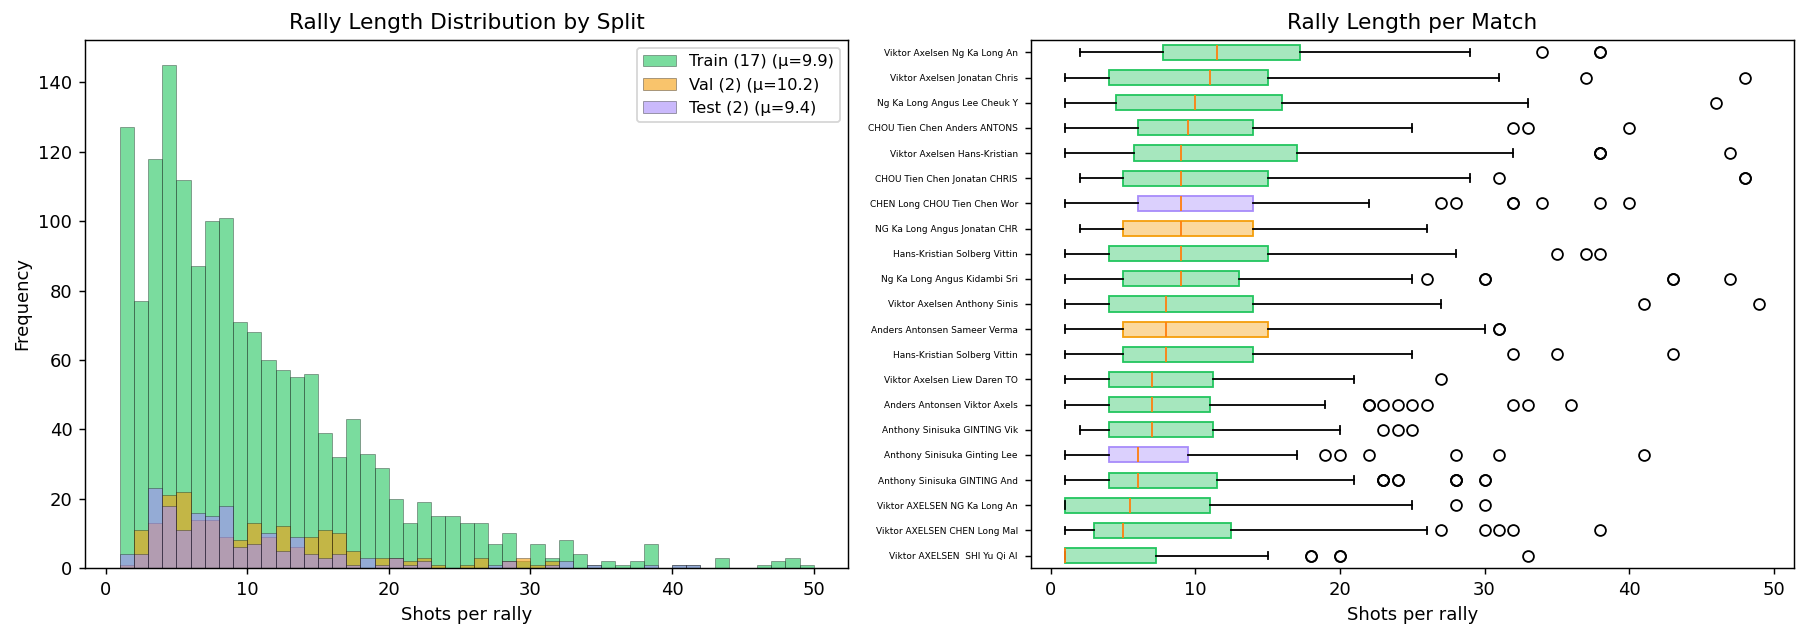

Total rallies: 1,974
Shots/rally — min: 1, median: 8, mean: 9.9, max: 49


In [8]:
# Set-aware rally grouping
rally_len = (strokes.groupby(['split','match_id','rally_uid'])
             .size().reset_index(name='n_shots'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sp in ('train', 'val', 'test'):
    sub = rally_len[rally_len['split'] == sp]
    axes[0].hist(sub['n_shots'], bins=range(1, rally_len['n_shots'].max() + 2),
                 alpha=0.6, label=f"{SPLIT_LABELS[sp]} (μ={sub['n_shots'].mean():.1f})",
                 color=SPLIT_COLORS[sp], edgecolor='black', linewidth=0.3)
axes[0].set_xlabel('Shots per rally')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Rally Length Distribution by Split')
axes[0].legend(fontsize=9)

match_order = rally_len.groupby('match_id')['n_shots'].median().sort_values().index
bp = axes[1].boxplot(
    [rally_len[rally_len['match_id'] == m]['n_shots'].values for m in match_order],
    vert=False, patch_artist=True, widths=0.6)
for i, m in enumerate(match_order):
    sp = active_matches[m]
    bp['boxes'][i].set_facecolor(SPLIT_COLORS[sp] + '66')
    bp['boxes'][i].set_edgecolor(SPLIT_COLORS[sp])
axes[1].set_yticklabels([m.replace('_',' ')[:28] for m in match_order], fontsize=5)
axes[1].set_xlabel('Shots per rally')
axes[1].set_title('Rally Length per Match')

plt.tight_layout()
plt.show()

print(f"Total rallies: {len(rally_len):,}")
print(f"Shots/rally — min: {rally_len['n_shots'].min()}, "
      f"median: {rally_len['n_shots'].median():.0f}, "
      f"mean: {rally_len['n_shots'].mean():.1f}, "
      f"max: {rally_len['n_shots'].max()}")

## 6. Shot Duration by Type

Shot duration pairs: 17,341
Duration (s) — median: 0.80, mean: 0.85, max: 24.93


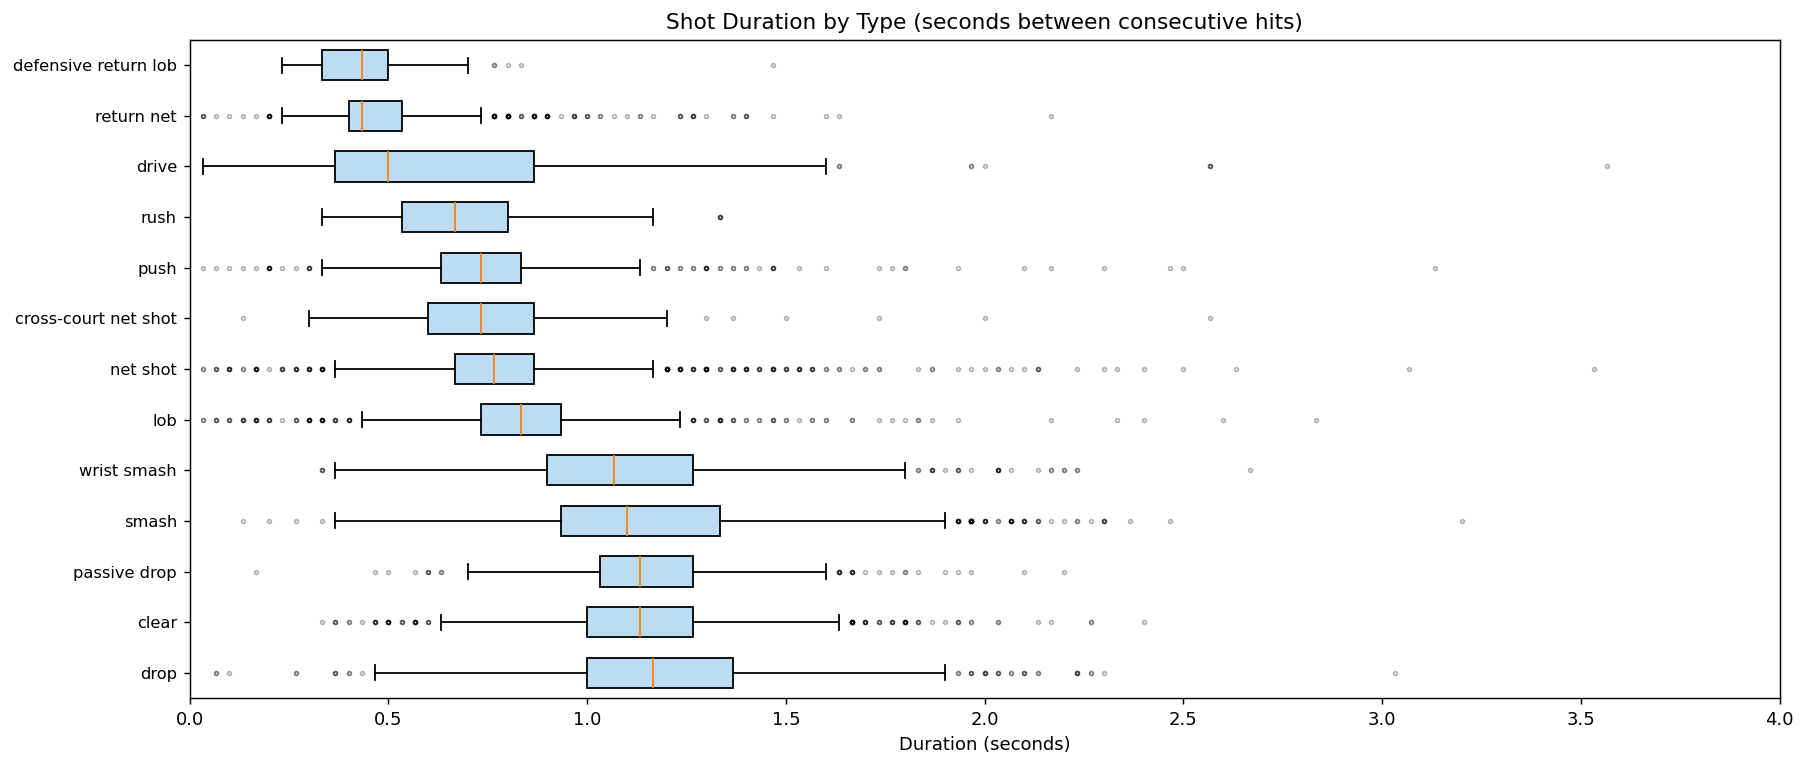


Shot type                      n   median     mean     std
-------------------------------------------------------
  drop                      1071     1.17     1.22    0.80
  clear                     1152     1.13     1.14    0.27
  passive drop               645     1.13     1.15    0.21
  smash                     1405     1.10     1.16    0.36
  wrist smash                866     1.07     1.10    0.32
  lob                       3039     0.83     0.83    0.19
  net shot                  3641     0.77     0.78    0.23
  cross-court net shot       701     0.73     0.72    0.21
  push                      1377     0.73     0.76    0.22
  rush                       335     0.67     0.67    0.18
  drive                     1003     0.50     0.63    0.35
  return net                1937     0.43     0.48    0.43
  defensive return lob       169     0.43     0.44    0.14


In [9]:
FPS = 30
durations = []
for (match_id, rally_uid), grp in strokes.groupby(['match_id','rally_uid']):
    grp = grp.sort_values('ball_round')
    frames = grp['frame_num'].values
    types  = grp['shot_type'].values
    sp     = grp['split'].iloc[0]
    for i in range(1, len(frames)):
        if pd.isna(frames[i]) or pd.isna(frames[i-1]): continue
        gap = frames[i] - frames[i-1]
        if gap <= 0 or pd.isna(types[i]): continue
        durations.append({'split': sp, 'shot_type': types[i],
                          'duration_s': gap / FPS})

dur_df = pd.DataFrame(durations)
print(f"Shot duration pairs: {len(dur_df):,}")
print(f"Duration (s) — median: {dur_df['duration_s'].median():.2f}, "
      f"mean: {dur_df['duration_s'].mean():.2f}, "
      f"max: {dur_df['duration_s'].max():.2f}")

type_order = dur_df.groupby('shot_type')['duration_s'].median().reindex(SHOT_TYPES).sort_values(ascending=False).dropna().index

fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot(
    [dur_df[dur_df['shot_type'] == t]['duration_s'].values for t in type_order],
    vert=False, patch_artist=True, widths=0.6,
    flierprops=dict(markersize=2, alpha=0.3))
for box in bp['boxes']:
    box.set_facecolor('#3498db55')
ax.set_yticklabels(type_order, fontsize=9)
ax.set_xlabel('Duration (seconds)')
ax.set_title('Shot Duration by Type (seconds between consecutive hits)')
ax.set_xlim(0, 4)
plt.tight_layout()
plt.show()

print(f"\n{'Shot type':<26} {'n':>5}  {'median':>7}  {'mean':>7}  {'std':>6}")
print("-"*55)
for t in type_order:
    sub = dur_df[dur_df['shot_type'] == t]['duration_s']
    print(f"  {t:<24} {len(sub):5d}  {sub.median():7.2f}  {sub.mean():7.2f}  {sub.std():6.2f}")

## 7. Class Imbalance Analysis

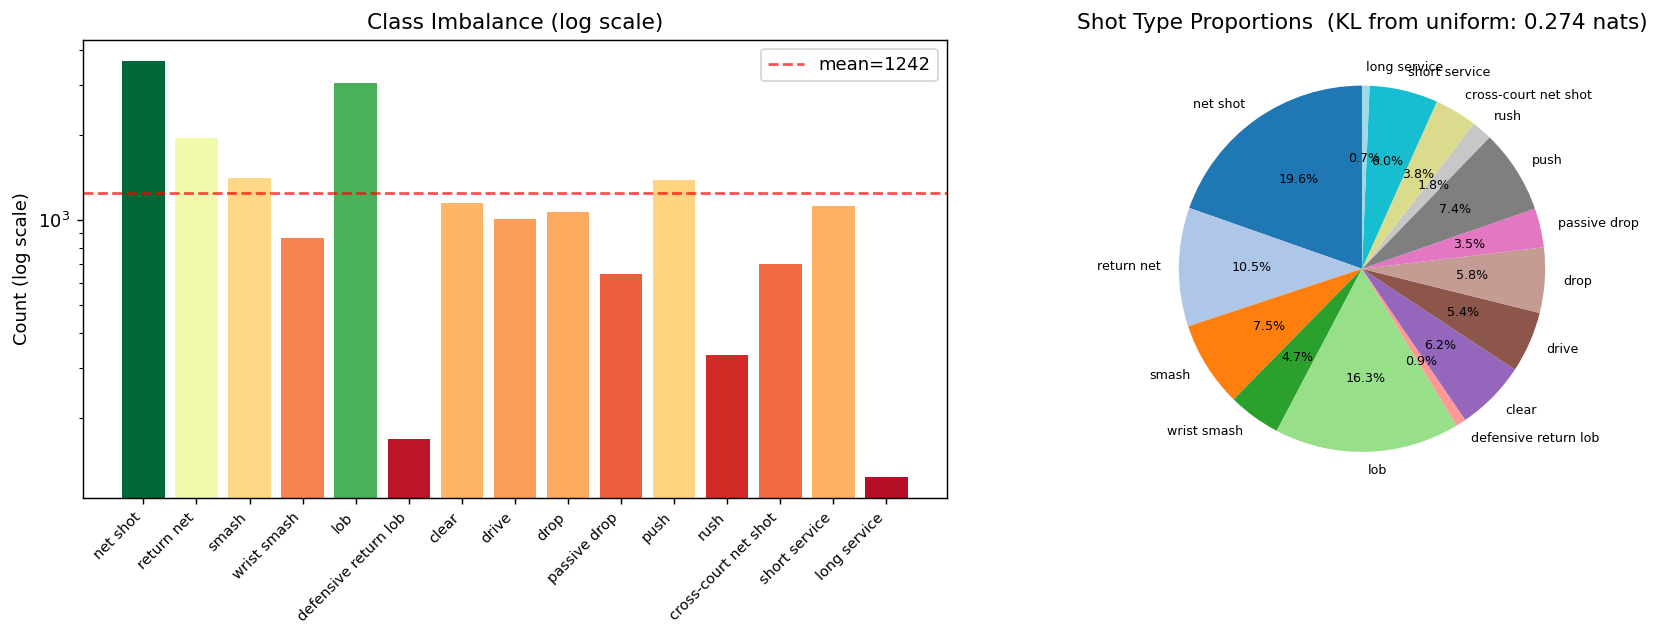

Shot type                   Count      %  vs_uniform
  net shot                   3655   19.6%       +2.9x
  lob                        3046   16.3%       +2.5x
  return net                 1953   10.5%       +1.6x
  smash                      1406    7.5%       +1.1x
  push                       1381    7.4%       +1.1x
  clear                      1152    6.2%       +0.9x
  short service              1125    6.0%       +0.9x
  drop                       1072    5.8%       +0.9x
  drive                      1005    5.4%       +0.8x
  wrist smash                 868    4.7%       +0.7x
  cross-court net shot        701    3.8%       +0.6x
  passive drop                645    3.5%       +0.5x
  rush                        335    1.8%       +0.3x
  defensive return lob        169    0.9%       +0.1x
  long service                124    0.7%       +0.1x

Imbalance ratio: 29.5x
KL divergence from uniform: 0.2742 nats


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-scale bar chart
ordered_counts_arr = np.array(ordered_counts)
colors_bar = plt.cm.RdYlGn(ordered_counts_arr / ordered_counts_arr.max())
axes[0].bar(range(len(SHOT_TYPES)), ordered_counts_arr, color=colors_bar)
axes[0].set_yscale('log')
axes[0].set_xticks(range(len(SHOT_TYPES)))
axes[0].set_xticklabels(SHOT_TYPES, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Class Imbalance (log scale)')
axes[0].axhline(np.mean(ordered_counts_arr), color='red', ls='--', alpha=0.7, label=f'mean={np.mean(ordered_counts_arr):.0f}')
axes[0].legend()

# KL divergence from uniform
from scipy.stats import entropy
uniform = np.ones(len(SHOT_TYPES)) / len(SHOT_TYPES)
p = ordered_counts_arr / ordered_counts_arr.sum()
kl = entropy(p, uniform)
axes[1].pie(ordered_counts_arr, labels=SHOT_TYPES, autopct='%1.1f%%',
            startangle=90, colors=plt.cm.tab20(np.linspace(0, 1, len(SHOT_TYPES))),
            textprops={'fontsize': 7})
axes[1].set_title(f'Shot Type Proportions  (KL from uniform: {kl:.3f} nats)')

plt.tight_layout()
plt.show()

# Counts sorted
print(f"{'Shot type':<26} {'Count':>6}  {'%':>5}  {'vs_uniform':>10}")
avg = total_labelled / len(SHOT_TYPES)
for s, n in sorted(zip(SHOT_TYPES, ordered_counts), key=lambda x: -x[1]):
    print(f"  {s:<24} {n:6d}  {n/total_labelled*100:5.1f}%  {n/avg:+9.1f}x")
print(f"\nImbalance ratio: {max(ordered_counts)/min(c for c in ordered_counts if c>0):.1f}x")
print(f"KL divergence from uniform: {kl:.4f} nats")

## 8. Summary

In [11]:
all_players = pd.concat([match_meta['winner'], match_meta['loser']]).value_counts()

print("=" * 65)
print("EDA SUMMARY — 21 Matches, 15-class vocabulary")
print("=" * 65)
for sp in ('train', 'val', 'test'):
    n_m  = sum(1 for v in active_matches.values() if v == sp)
    n_r  = rally_len[rally_len['split'] == sp]['rally_uid'].nunique()
    n_s  = int(strokes[strokes['split'] == sp].shape[0])
    n_l  = int(strokes[strokes['split'] == sp]['shot_type'].notna().sum())
    print(f"  {sp:6s}: {n_m} matches  {n_r} rallies  {n_s:,} shots  ({n_l:,} labelled)")
print(f"\nTotal shots          : {len(strokes):,}")
print(f"Labelled shots       : {total_labelled:,}")
print(f"Unknown (skipped)    : {strokes['shot_type'].isna().sum():,}")
print(f"Unique shot types    : {NUM_SHOT_TYPES} (15-class, drive merged)")
print(f"Avg shots/rally      : {rally_len['n_shots'].mean():.1f}")
print(f"Imbalance ratio      : {max(ordered_counts)/min(c for c in ordered_counts if c>0):.1f}x")
print(f"Unique players       : {len(all_players)}")
print(f"\nDrive merge: 平球({type_counts.get('drive',0)} after merge)")
print("  平球 + 後場抽平球 + 防守回抽 + 小平球 → drive")
print("=" * 65)

EDA SUMMARY — 21 Matches, 15-class vocabulary
  train : 17 matches  195 rallies  15,640 shots  (14,933 labelled)
  val   : 2 matches  118 rallies  2,155 shots  (2,077 labelled)
  test  : 2 matches  110 rallies  1,675 shots  (1,627 labelled)

Total shots          : 19,470
Labelled shots       : 18,637
Unknown (skipped)    : 833
Unique shot types    : 15 (15-class, drive merged)
Avg shots/rally      : 9.9
Imbalance ratio      : 29.5x
Unique players       : 14

Drive merge: 平球(1005 after merge)
  平球 + 後場抽平球 + 防守回抽 + 小平球 → drive


In [12]:
# Per-match Split / Match / Shots / Labelled / Rallies table (for report)
SPLIT_ORDER = {'test': 0, 'train': 1, 'val': 2}

per_match = (strokes.groupby(['split', 'match_id'])
             .agg(shots=('type', 'count'),
                  labelled=('shot_type', 'count'),
                  rallies=('rally_uid', 'nunique'))
             .reset_index())
per_match['_ord'] = per_match['split'].map(SPLIT_ORDER)
per_match = per_match.sort_values(['_ord', 'match_id']).drop(columns='_ord').reset_index(drop=True)

def _pretty(name):
    """Underscore_name → 'A vs B -- Tournament Year Round' (best-effort)."""
    s = name.replace('_', ' ').strip()
    s = ' '.join(s.split())
    return s

print(f"{'Split':<6} {'Shots':>6} {'Labelled':>9} {'Rallies':>8}  Match")
print("-" * 110)
for _, r in per_match.iterrows():
    print(f"{r['split']:<6} {r['shots']:>6} {r['labelled']:>9} {r['rallies']:>8}  {_pretty(r['match_id'])[:80]}")

tot_shots    = int(per_match['shots'].sum())
tot_labelled = int(per_match['labelled'].sum())
tot_rallies  = int(per_match['rallies'].sum())
print("-" * 110)
print(f"{'TOTAL':<6} {tot_shots:>6} {tot_labelled:>9} {tot_rallies:>8}")

# LaTeX block for the report
print("\n\n% ── LaTeX (paste into report) ─────────────────────────────────────")
print(r"\begin{table}[H]")
print(r"\centering")
print(r"\caption{Dataset split by match.}")
print(r"\label{tab:dataset-split}")
print(r"\small")
print(r"\setlength{\tabcolsep}{4pt}")
print(r"\begin{tabular}{| l | p{0.58\textwidth} | r | r | r |}")
print(r"\hline")
print(r"\textbf{Split} & \textbf{Match} & \textbf{Shots} & \textbf{Labelled} & \textbf{Rallies} \\")
print(r"\hline")
for _, r in per_match.iterrows():
    print(rf"\textbf{{{r['split']}}} & {_pretty(r['match_id'])} "
          rf"& {r['shots']:,} & {r['labelled']:,} & {r['rallies']:,} \\")
    print(r"\hline")
print(rf" & \textbf{{TOTAL}} & \textbf{{{tot_shots:,}}} "
      rf"& \textbf{{{tot_labelled:,}}} & \textbf{{{tot_rallies:,}}} \\")
print(r"\hline")
print(r"\end{tabular}")
print(r"\end{table}")

Split   Shots  Labelled  Rallies  Match
--------------------------------------------------------------------------------------------------------------
test      815       779      103  Anthony Sinisuka Ginting Lee Zii Jia HSBC BWF WORLD TOUR FINALS 2020 QuarterFina
test      860       848       75  CHEN Long CHOU Tien Chen World Tour Finals Group Stage
train     895       872      101  Anders Antonsen Viktor Axelsen HSBC BWF WORLD TOUR FINALS 2020 Finals
train    1424      1399      176  Anthony Sinisuka GINTING Anders ANTONSEN Indonesia Masters 2020 Final
train     506       506       60  Anthony Sinisuka GINTING Viktor AXELSEN Indonesia Masters 2020 SemiFinals
train     704       686       64  CHOU Tien Chen Anders ANTONSEN Fuzhou Open 2019 Semi-finals
train    1219      1152      111  CHOU Tien Chen Jonatan CHRISTIE Indonesia Open 2019 Quarter-finals
train     735       679       69  Hans-Kristian Solberg Vittinghus Anders Antonsen TOYOTA THAILAND OPEN 2021 SemiF
train    1273      